# Numpy and Matplotlib


---




**Numpy** is a numerical calculus and algebra package that is widely used, notably providing the *array* (vector/matrix format) type used in almost all numerical projects.  [Documentation](https://numpy.org/doc/stable/) and [Reference](https://numpy.org/doc/stable/reference/index.html)


**Matplotlib** is a module for generating 2D and 3D graphics. [Documentation ](https://matplotlib.org/stable/contents.html)


It is common to import them with the respective nicknames **np** and **plt** (for `matplotlib.pyplot`).

In [99]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

The last line `%matplotlib inline` is a command for Jupyter to indicate that we want our figures in the notebook and not in a separate window.

## Numpy *arrays*

In Numpy, the type *array* is used for vector, matrices, tensors (a matrix type also exists but is more seldomly used).

Numpy arrays can be defined either directly from a list or outputted by a function.


### One-dimensional arrays

In [100]:
x = np.array([1, 2.5, 5, 10])
print(x,type(x))

[ 1.   2.5  5.  10. ] <class 'numpy.ndarray'>


In [101]:
y = np.random.rand(4)
print(y,type(y))

[0.83398564 0.5702639  0.5326207  0.21576855] <class 'numpy.ndarray'>


## Plotting

Visualizing the data is quite simple with pyplot:
* Initialize a figure with  `plt.figure()`
* Plot something with ... `plt.plot` (see the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html?highlight=pyplot#module-matplotlib.pyplot) )
* Fix labels, titles, axes
* Eventually save the result with `plt.savefig`
* Show the figure with `plt.show()`

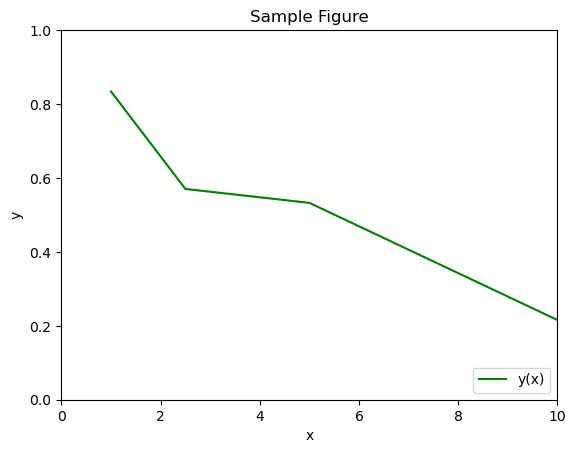

In [102]:
plt.figure()

plt.plot(x,y, 'g', label='y(x)')

plt.legend(loc='lower right')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sample Figure')
plt.xlim([0, 10])
plt.ylim([0, 1])
plt.savefig('img/sample2.png')
plt.show()

## Matrices

Matrices are simply 2D arrays. Since vectors and matrices share the same type, the notion of *shape* is very important.

In [103]:
M = np.array([[0.25, 6.2, 1, 10],[12, 6.2, 6, -5.3]])
print(M,type(M))

[[ 0.25  6.2   1.   10.  ]
 [12.    6.2   6.   -5.3 ]] <class 'numpy.ndarray'>


In [104]:
print(x,type(x))

[ 1.   2.5  5.  10. ] <class 'numpy.ndarray'>


* The `size` of an array is the number of elements while the `shape` gives how they are arranged.

In [105]:
print(x.size)  # or equivalently np.size(x)
print(M.size)

4
8


In [106]:
print(x.shape)  # or equivalently np.shape(x)
print(M.shape)

(4,)
(2, 4)


* The element access, assignment, type, copy is common and similar to the list type.

In [107]:
print(x)
print(x[2],x[-1])
print(x[::-1])
x[0] = 6.1554
print(x)

[ 1.   2.5  5.  10. ]
5.0 10.0
[10.   5.   2.5  1. ]
[ 6.1554  2.5     5.     10.    ]


In [108]:
v = x
w = np.copy(x)
print(v)
x[0]=1
print(v)
print(w)

[ 6.1554  2.5     5.     10.    ]
[ 1.   2.5  5.  10. ]
[ 6.1554  2.5     5.     10.    ]


In [109]:
print(M)
print(M[1,2],type(M[1,2]))
print(M[1,:],type(M[1,:]),M[1,:].shape)
print(M[1])
print(M[:,0])

[[ 0.25  6.2   1.   10.  ]
 [12.    6.2   6.   -5.3 ]]
6.0 <class 'numpy.float64'>
[12.   6.2  6.  -5.3] <class 'numpy.ndarray'> (4,)
[12.   6.2  6.  -5.3]
[ 0.25 12.  ]


Advanced access to content and modification is possible

In [110]:
x = np.array([1, 2.5, 5, 10])
ind = [0,2,3]
print(x[ind])

[ 1.  5. 10.]


### Advanced array properties [*]


An array has a *type* that can be accessed with <tt>dtype</tt>, it the combination of a base type (<tt>int, float, complex, bool, object,</tt> etc.) and a precision in bits (<tt>int64, int16, float128, complex128</tt>)

In [111]:
print(x.dtype)

float64


Array only accept they casting to their own type. However, the type of an array can be changed.

In [112]:
try:
    x[0] = 1 + 2.0j
except Exception as e:
    print(e)

float() argument must be a string or a real number, not 'complex'


In [113]:
y = x.astype(complex)
y[0] = 1 + 2.0j
print(y,type(y),y.dtype)

[ 1. +2.j  2.5+0.j  5. +0.j 10. +0.j] <class 'numpy.ndarray'> complex128


## Numpy array generation

See the corresponding [documentation](https://numpy.org/doc/stable/user/basics.creation.html)

### Number sequences


`arange` returns an array of evenly spaced number from `start` to (at most) `stop` with a fixed jump `step`


`linspace` returns an array of evenly spaced number from `start` to (exactly) `stop` with a fixed number of points `num`

In [114]:
x = np.arange(0, 10, 1.5)
print(x,type(x))

[0.  1.5 3.  4.5 6.  7.5 9. ] <class 'numpy.ndarray'>


In [115]:
y = np.linspace(0, 10, 25)
print(y,type(y))

[ 0.          0.41666667  0.83333333  1.25        1.66666667  2.08333333
  2.5         2.91666667  3.33333333  3.75        4.16666667  4.58333333
  5.          5.41666667  5.83333333  6.25        6.66666667  7.08333333
  7.5         7.91666667  8.33333333  8.75        9.16666667  9.58333333
 10.        ] <class 'numpy.ndarray'>


### Zeros and Ones


`zeros` returns an array (of floats) of zeros  of the precised `shape`

`ones`  returns an array (of floats) of ones  of the precised `shape`

`eye`  returns a square 2D-array (of floats) with ones on the diagonal and zeros elsewhere  

In [116]:
x = np.zeros(3)
print(x,x.shape,type(x),x.dtype)

x = np.zeros((3,))
print(x,x.shape,type(x),x.dtype)

[0. 0. 0.] (3,) <class 'numpy.ndarray'> float64
[0. 0. 0.] (3,) <class 'numpy.ndarray'> float64


In [117]:
try:
    x = np.zeros(3,3) # This causes an error as 3,3 is not a shape, it is (3,3) -> double parentheses
except Exception as error:
    print(error)

print(x,x.shape,type(x),x.dtype)

Cannot interpret '3' as a data type
[0. 0. 0.] (3,) <class 'numpy.ndarray'> float64


In [118]:
x = np.zeros((3,3))
print(x,x.shape,type(x),x.dtype)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] (3, 3) <class 'numpy.ndarray'> float64


In [119]:
y = np.ones(2)
y

array([1., 1.])

In [120]:
M = np.eye(3)
print(M,M.shape,type(M),M.dtype)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] (3, 3) <class 'numpy.ndarray'> float64


### Random data


Random arrays can be generated by Numpy's [random](https://numpy.org/doc/stable/reference/random/index.html) module.


`rand` returns an array (of floats) of uniformly distributed numbers in [0,1)  of the precised dimension

`randn`  returns an array (of floats) of numbers from the normal distribution of the precised dimension

`randint`  returns an array (of floats) of integers from the discrete uniform distribution

In [121]:
np.random.rand(5)

array([0.53370027, 0.20044017, 0.61242131, 0.02624743, 0.02067476])

In [122]:
np.random.randn(5,2)

array([[-0.74437877, -1.00785239],
       [-1.51450843, -1.28834609],
       [ 0.03348787,  1.57291127],
       [ 1.14994836,  2.24750632],
       [ 0.48044378, -0.20489502]])

In [123]:
np.random.randint(0,100,size=(10,))

array([76, 79, 16, 90, 48, 34, 27, 31, 83, 87], dtype=int32)

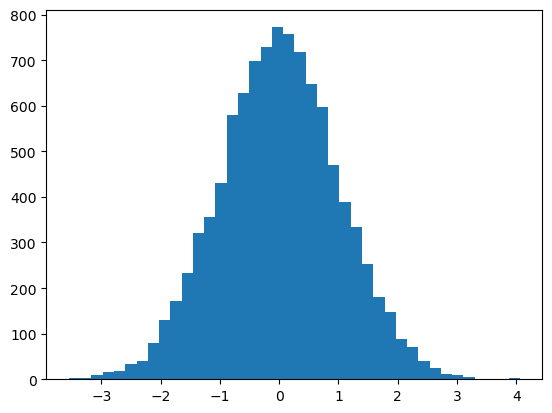

In [124]:
a = np.random.randn(10000)
plt.figure()
plt.hist(a,40) # histogram of a with 40 bins
plt.show()

## Operations on Matrices and vectors


In [125]:
v = np.arange(0, 5)
print(v)

[0 1 2 3 4]


In [126]:
v * 2

array([0, 2, 4, 6, 8])

In [127]:
v + 2.5

array([2.5, 3.5, 4.5, 5.5, 6.5])

In [128]:
square = v**2
root = np.sqrt(v)
print(square,root)

[ 0  1  4  9 16] [0.         1.         1.41421356 1.73205081 2.        ]


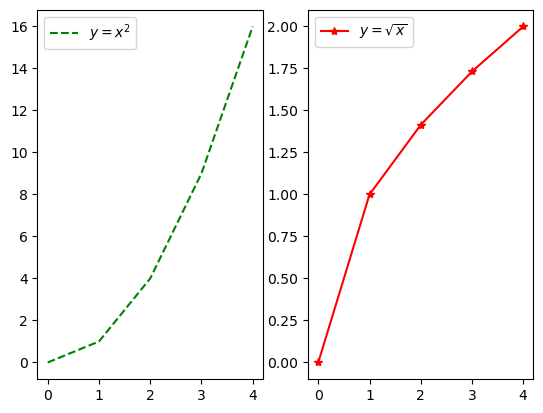

In [129]:
plt.figure()
plt.subplot(1,2,1)
plt.plot(square,'g--', label='$y = x^2$')
plt.legend(loc=0)
plt.subplot(1,2,2)
plt.plot(root, 'r*-', label='$y = \sqrt{x}$')
plt.legend(loc=2)
plt.show()

In [130]:
A = np.array([[n+m*10 for n in range(5)] for m in range(4)])
print(A)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


In [131]:
A*2

array([[ 0,  2,  4,  6,  8],
       [20, 22, 24, 26, 28],
       [40, 42, 44, 46, 48],
       [60, 62, 64, 66, 68]])

In [132]:
A+5.5

array([[ 5.5,  6.5,  7.5,  8.5,  9.5],
       [15.5, 16.5, 17.5, 18.5, 19.5],
       [25.5, 26.5, 27.5, 28.5, 29.5],
       [35.5, 36.5, 37.5, 38.5, 39.5]])

Matrices can be visualized as images.

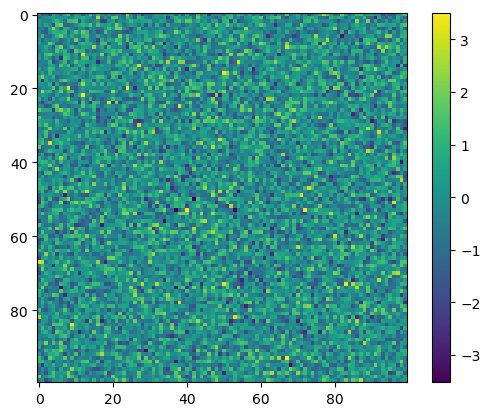

In [133]:
C = np.random.randn(100,100)
plt.figure()
plt.imshow(C)
plt.colorbar()
plt.show()

## Matrix and vector operations



*Warning:* Operation symbols `+   -   *  /` correspond to *elementwise* operations! To perform, matrix/vector multiplication, dedicated function must be used.

### Elementwise operations

In [134]:
A = np.array([[n+m*10 for n in range(5)] for m in range(4)])
v = np.random.randint(0,5,5)
print(A,v)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]] [1 3 3 0 1]


In [135]:
A*A

array([[   0,    1,    4,    9,   16],
       [ 100,  121,  144,  169,  196],
       [ 400,  441,  484,  529,  576],
       [ 900,  961, 1024, 1089, 1156]])

In [136]:
v*v

array([1, 9, 9, 0, 1], dtype=int32)

In [137]:
A*v

array([[ 0,  3,  6,  0,  4],
       [10, 33, 36,  0, 14],
       [20, 63, 66,  0, 24],
       [30, 93, 96,  0, 34]])

### Transposition

It can be useful to transpose, it is simply done by suffixing `.T` (or equivalently using the function `np.transpose`). Similarly `.H` is the Hermitian conjugate,  `.imag`  `.real` are the real and imaginary parts and  `.abs` the modulus (their *full* versions are respectively `np.conjugate`, `np.imag`, etc.)

In [138]:
print(A,A.shape)
print(A.T,A.T.shape)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]] (4, 5)
[[ 0 10 20 30]
 [ 1 11 21 31]
 [ 2 12 22 32]
 [ 3 13 23 33]
 [ 4 14 24 34]] (5, 4)


### Matrix/vector operations

$y=Av$ can be obtained by `y = A.dot(v)` (or equivalently `y = np.dot(A,v)`). This methods works for array with *compatible shape* (matrix-matrix, matrix-vector, vector-matrix, vector-vector, etc).


In [139]:
y = np.dot(A,v)
print(A,A.shape,v,v.shape)
print(y,type(y),y.shape)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]] (4, 5) [1 3 3 0 1] (5,)
[ 13  93 173 253] <class 'numpy.ndarray'> (4,)


Example of vector-vector multiplication i.e. a scalar product

In [140]:
s = v.dot(v)
print(v, s, type(s))

[1 3 3 0 1] 20 <class 'numpy.int32'>


Example of non-compatible shapes

In [141]:
try:
    A2 = np.dot(A,A)
except Exception as error:
    print(error)

shapes (4,5) and (4,5) not aligned: 5 (dim 1) != 4 (dim 0)


In [142]:
A3 = np.dot(A,A.T)
print(A3,A3.shape)

[[  30  130  230  330]
 [ 130  730 1330 1930]
 [ 230 1330 2430 3530]
 [ 330 1930 3530 5130]] (4, 4)


From a vector $v$, one can form the matrix $P=v v^T$ by `A=v.outer(v)` (or equivalently `np.outer(v,v)`)

In [143]:
P = np.outer(v,v)
print(P)

[[1 3 3 0 1]
 [3 9 9 0 3]
 [3 9 9 0 3]
 [0 0 0 0 0]
 [1 3 3 0 1]]


### Useful Functions

See the Documentation on [arrays](https://numpy.org/doc/stable/reference/arrays.ndarray.html)  and  [array creation](https://numpy.org/doc/stable/reference/routines.array-creation.html).

*Warning:* Modificators such as transpose, reshape, etc. do not modify the matrix, if you want to keep the result of the operation, you have to assign a variable to it. The notable exceptions are precised as *in-place* in the documentation.

In [144]:
A.reshape((2,10))

array([[ 0,  1,  2,  3,  4, 10, 11, 12, 13, 14],
       [20, 21, 22, 23, 24, 30, 31, 32, 33, 34]])

In [145]:
print(A)

[[ 0  1  2  3  4]
 [10 11 12 13 14]
 [20 21 22 23 24]
 [30 31 32 33 34]]


In [146]:
B = A.flatten()
print(B)

[ 0  1  2  3  4 10 11 12 13 14 20 21 22 23 24 30 31 32 33 34]


In [147]:
print(A.trace(),A.max(),A.argmax())

66 34 19


Some functions may be taken with respects to the columns with <tt>axis=0</tt> or lines with <tt>axis=1</tt>.

In [148]:
print(A.mean(),A.mean(axis=0),A.mean(axis=1))

17.0 [15. 16. 17. 18. 19.] [ 2. 12. 22. 32.]


In [149]:
print(A.var(),A.var(axis=0),A.std(axis=1))

127.0 [125. 125. 125. 125. 125.] [1.41421356 1.41421356 1.41421356 1.41421356]


### Repetition, concatenation

In [150]:
a = np.array([[1, 2], [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [151]:
b = np.array([[5, 6]])
b

array([[5, 6]])

In [152]:
np.concatenate((a, b), axis=0)

array([[1, 2],
       [3, 4],
       [5, 6]])

In [153]:
np.concatenate((a, b.T), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

In [154]:
np.vstack((a,b))

array([[1, 2],
       [3, 4],
       [5, 6]])

In [155]:
np.hstack((a,b.T))

array([[1, 2, 5],
       [3, 4, 6]])

### Iterating on arrays

In [156]:
v = np.array([1,2,3,4])

for element in v:
    print(element)

1
2
3
4


In [157]:
a = np.array([[1,2], [3,4]])

for row in a:
    print("row", row)

    for element in row:
        print(element)

row [1 2]
1
2
row [3 4]
3
4


<tt>enumerate</tt> can be used to get indexes along with elements.

In [158]:
for row_idx, row in enumerate(a):
    print("row_idx", row_idx, "row", row)

    for col_idx, element in enumerate(row):
        print("col_idx", col_idx, "element", element)

        # update the matrix a: square each element
        a[row_idx, col_idx] = element ** 2

row_idx 0 row [1 2]
col_idx 0 element 1
col_idx 1 element 2
row_idx 1 row [3 4]
col_idx 0 element 3
col_idx 1 element 4


In [159]:
a

array([[ 1,  4],
       [ 9, 16]])

# 3- Linear Algebra


Numpy comes with an efficient linear algebra module named `linalg` (see the [documentation](https://numpy.org/doc/stable/reference/routines.linalg.html) ). As in many languages, the more vectorized the operations are, the more efficient.

## Decompositions


* *QR:* `linalg.qr` Factor the matrix $A$ as $QR$, where $Q$ is orthonormal and $R$ is upper-triangular.
* *Cholesky:* `linalg.cholesky` Return the Cholesky decomposition, $L L^H$, of the square matrix $A$, where $L$ is lower-triangular. $A$ must be Hermitian and positive-definite. Only $L$ is actually returned.
* *SVD:* `linalg.svd`  Factors the matrix $A$ as $U  \text{diag}(s) V$, where $U$ and $V$ are unitary and $s$ is a 1-d array of $A$‘s singular values.



In [160]:
A = np.random.randn(3,2)

In [161]:
Q, R = np.linalg.qr(A)
print(A)
print(Q)
print(R)

[[ 0.27831443  0.61759271]
 [ 0.07949849 -1.31591514]
 [ 0.42278766  0.72003871]]
[[-0.54318482  0.15406963]
 [-0.1551568  -0.98450847]
 [-0.82515248  0.08369956]]
[[-0.51237519 -0.72543553]
 [ 0.          1.4509488 ]]


In [162]:
np.allclose(A, np.dot(Q, R)) # check that A=QR

True

In [163]:
U, s, V = np.linalg.svd(A)
print(U.shape, V.shape, s.shape)

(3, 3) (2, 2) (2,)


In [164]:
S = np.zeros(A.shape)
S[:A.shape[1], :A.shape[1]] = np.diag(s)
np.allclose(A, np.dot(U, np.dot(S, V)))

True

By default, $U$ and $V$ have the shapes $(M, M)$ and $(N, N)$  respectively if $A$ is $(M,N)$. If `full_matrices=False` is passed, the shapes are $(M, K)$ and $(K, N)$, respectively, where $K = min(M, N)$.

In [165]:
U, s, V = np.linalg.svd(A, full_matrices=False)
print(U.shape, V.shape, s.shape)

(3, 2) (2, 2) (2,)


In [166]:
S = np.diag(s)
np.allclose(A, np.dot(U, np.dot(S, V)))

True

## Eigenvalues

`linalg.eig` compute the eigenvalues and right eigenvectors of a square array and is the main function (`linalg.eigvals` computes eigenvalues of a non-symmetric array, `linalg.eigh` returns eigenvalues and eigenvectors of a symmetric or Hermitian array).

In [167]:
A = np.array([[1, -1], [1, 1]])
print(A)
l, v = np.linalg.eig(A)
print(l); print(v)

[[ 1 -1]
 [ 1  1]]
[1.+1.j 1.-1.j]
[[0.70710678+0.j         0.70710678-0.j        ]
 [0.        -0.70710678j 0.        +0.70710678j]]


In [168]:
A.dot(v[:,0])

array([0.70710678+0.70710678j, 0.70710678-0.70710678j])

We can check that $Ax= \lambda x$.

In [169]:
np.allclose(A.dot(v[:,0]),l[0]*v[:,0])

True

## Norms and other numbers

The function `linalg.norm` is able to return one of eight different matrix norms, or one of an infinite number of vector norms (described below), depending on the value of the `ord` parameter.

<table border="1" class="docutils">
<colgroup>
<col width="8%" />
<col width="47%" />
<col width="44%" />
</colgroup>
<thead valign="bottom">
<tr class="row-odd"><th class="head">ord</th>
<th class="head">norm for matrices</th>
<th class="head">norm for vectors</th>
</tr>
</thead>
<tbody valign="top">
<tr class="row-even"><td>None</td>
<td>Frobenius norm</td>
<td>2-norm</td>
</tr>
<tr class="row-odd"><td>&#8216;fro&#8217;</td>
<td>Frobenius norm</td>
<td>&#8211;</td>
</tr>
<tr class="row-even"><td>&#8216;nuc&#8217;</td>
<td>nuclear norm</td>
<td>&#8211;</td>
</tr>
<tr class="row-odd"><td>inf</td>
<td>max(sum(abs(x), axis=1))</td>
<td>max(abs(x))</td>
</tr>
<tr class="row-even"><td>-inf</td>
<td>min(sum(abs(x), axis=1))</td>
<td>min(abs(x))</td>
</tr>
<tr class="row-odd"><td>0</td>
<td>&#8211;</td>
<td>sum(x != 0)</td>
</tr>
<tr class="row-even"><td>1</td>
<td>max(sum(abs(x), axis=0))</td>
<td>as below</td>
</tr>
<tr class="row-odd"><td>-1</td>
<td>min(sum(abs(x), axis=0))</td>
<td>as below</td>
</tr>
<tr class="row-even"><td>2</td>
<td>2-norm (largest sing. value)</td>
<td>as below</td>
</tr>
<tr class="row-odd"><td>-2</td>
<td>smallest singular value</td>
<td>as below</td>
</tr>
<tr class="row-even"><td>other</td>
<td>&#8211;</td>
<td>sum(abs(x)$^{ord}$)$^{(1./ord)}$</td>
</tr>
</tbody>
</table>

In [170]:
a = np.arange(9) - 4
B = a.reshape((3, 3))

In [171]:
print(a)
print("none \t",np.linalg.norm(a))
print("2 \t",np.linalg.norm(a,ord=2))
print("1 \t",np.linalg.norm(a,ord=1))
print("inf \t",np.linalg.norm(a,ord=np.inf))
print("0 \t",np.linalg.norm(a,ord=0))

[-4 -3 -2 -1  0  1  2  3  4]
none 	 7.745966692414834
2 	 7.745966692414834
1 	 20.0
inf 	 4.0
0 	 8.0


In [172]:
print(B)
print("none \t",np.linalg.norm(B))
print("2 \t",np.linalg.norm(B,ord=2))
print("1 \t",np.linalg.norm(B,ord=1))
print("inf \t",np.linalg.norm(B,ord=np.inf))
print("fro \t",np.linalg.norm(B,ord='fro'))

[[-4 -3 -2]
 [-1  0  1]
 [ 2  3  4]]
none 	 7.745966692414834
2 	 7.348469228349534
1 	 7.0
inf 	 9.0
fro 	 7.745966692414834


Other useful function include the condition number `linalg.cond`, or rank `linalg.matrix_rank` .

In [173]:
A = np.array([[1, 0, -1], [0, 1, 0], [1, 0, 1]]) # some matrix
I = np.eye(4) # identity
Def =  np.eye(4); Def[0,0]=0 # rank deficient

In [174]:
print(np.linalg.cond(A), np.linalg.cond(I))

1.4142135623730951 1.0


In [175]:
np.linalg.cond(Def)

np.float64(inf)

In [176]:
print(np.linalg.matrix_rank(A), np.linalg.matrix_rank(I), np.linalg.matrix_rank(Def))

3 4 3


#Practice Tasks

In [177]:
#Create a NumPy array of integers from 1 to 10.
n = np.array([1,2,3,4,5,6,7,8,9,10])
print(n)
#Use the .reshape() method to change the shape of the array to a 2x5 matrix.
rs = n.reshape((2,5))
rs

[ 1  2  3  4  5  6  7  8  9 10]


array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [178]:
#Create a 5x5 NumPy array filled with random integers between 1 and 100.
#Extract the middle 3x3 section of the array using slicing.
arr = np.random.randint(1, 101, (5, 5))
print(arr)

middle = arr[1:4, 1:4]
print(middle)

[[85  1 98 35 40]
 [93  4 82 92 66]
 [14 42 79 74 15]
 [34 63 30 92 84]
 [76 62 72 94 33]]
[[ 4 82 92]
 [42 79 74]
 [63 30 92]]


In [179]:
#Given two arrays: a = np.array([1, 2, 3, 4, 5]) and 
# b = np.array([6, 7, 8, 9, 10]), compute the element-wise sum, 
# difference, product, and division of a and b.
a = np.array([1, 2, 3, 4, 5])
b = np.array([6, 7, 8, 9, 10])

# Element-wise operations
sum = a + b
diff = a - b
prod = a * b
divi = a / b

# Display results
print("Array a:", a)
print("Array b:", b)

print(sum)
print(diff)
print(prod)
print(divi)

Array a: [1 2 3 4 5]
Array b: [ 6  7  8  9 10]
[ 7  9 11 13 15]
[-5 -5 -5 -5 -5]
[ 6 14 24 36 50]
[0.16666667 0.28571429 0.375      0.44444444 0.5       ]


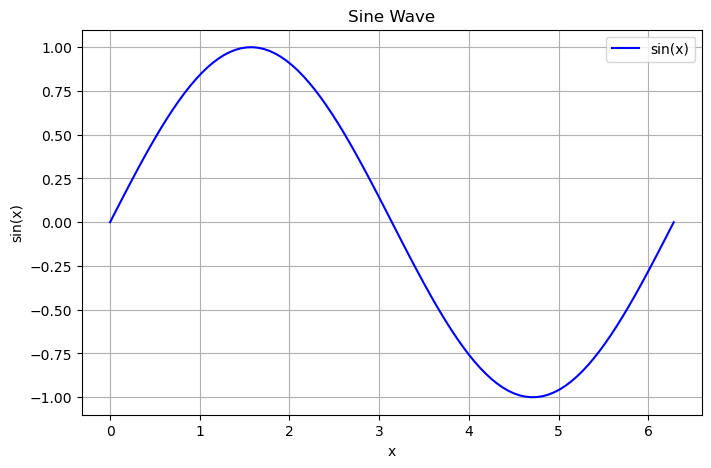

In [180]:
#Plot the sine wave for x values ranging from 0 to 2*pi. Use 100 points and display the plot with appropriate labels for the x and y axes.
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)
# Plot the sine wave
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='sin(x)', color='blue')

plt.title("Sine Wave")
plt.xlabel("x")
plt.ylabel("sin(x)")

plt.grid(True)
plt.legend()
plt.show()

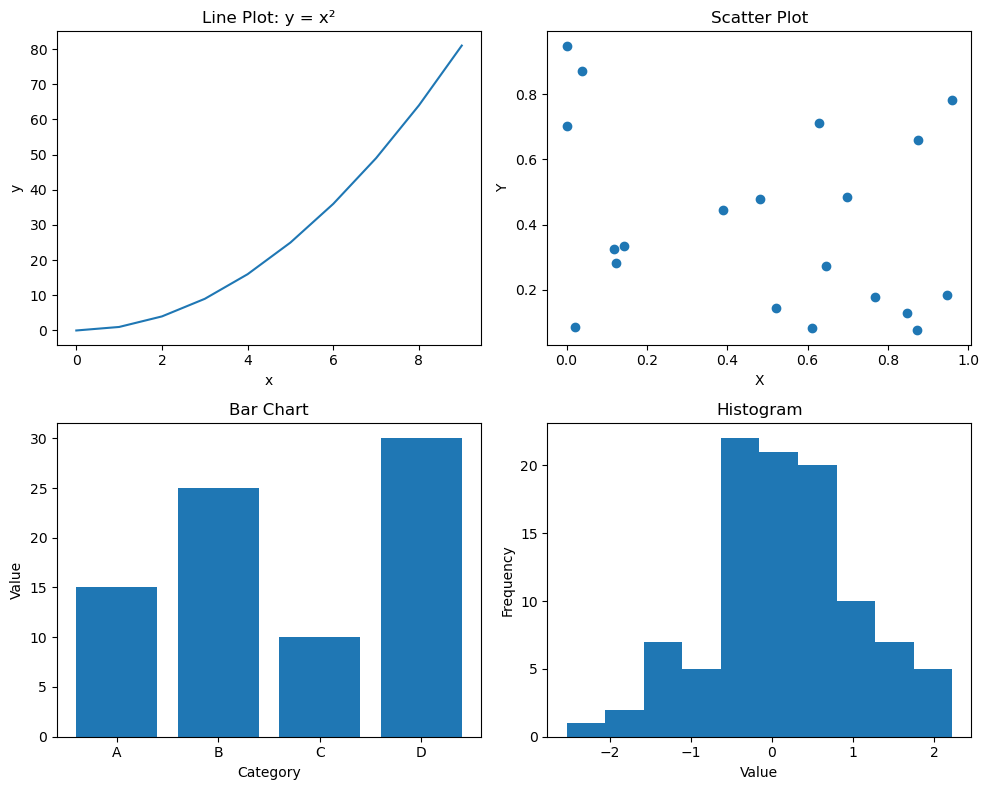

In [181]:
#Create a 2x2 subplot layout in Matplotlib and display the following in each subplot:
#A line plot of y = x^2.
#A scatter plot of random points.
#A bar chart of some arbitrary data.
#A histogram of random numbers.
x = np.arange(0, 10)
plt.figure(figsize=(10, 8))

# 1. Line Plot: y = x²
plt.subplot(2, 2, 1)
plt.plot(x, x**2)
plt.title("Line Plot: y = x²")
plt.xlabel("x")
plt.ylabel("y")

# 2. Scatter Plot of Random Points
plt.subplot(2, 2, 2)
x_scatter = np.random.rand(20)
y_scatter = np.random.rand(20)
plt.scatter(x_scatter, y_scatter)
plt.title("Scatter Plot")
plt.xlabel("X")
plt.ylabel("Y")

# 3. Bar Chart
plt.subplot(2, 2, 3)
categories = ['A', 'B', 'C', 'D']
values = [15, 25, 10, 30]
plt.bar(categories, values)
plt.title("Bar Chart")
plt.xlabel("Category")
plt.ylabel("Value")

# 4. Histogram
plt.subplot(2, 2, 4)
data = np.random.randn(100)
plt.hist(data, bins=10)
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Adjust spacing and display
plt.tight_layout()
plt.show()

In [182]:
#Create a NumPy array of 50 random numbers. Use np.mean(), np.median(), and np.std() to compute the mean, median, and standard deviation of the array.
arr = np.random.rand(50)

mean = np.mean(arr)
median = np.median(arr)
std_dev = np.std(arr)

print(arr)

# Display the results
print(mean)
print(median)
print(std_dev)

[0.09219198 0.3465855  0.09839709 0.99634466 0.5513252  0.05707249
 0.42587085 0.53941562 0.2952905  0.05159448 0.53215726 0.29396141
 0.74343355 0.5453452  0.26853312 0.04493782 0.585274   0.42643493
 0.68849301 0.26021271 0.66720867 0.79007654 0.92789359 0.34282505
 0.66239    0.14859458 0.81033418 0.63644392 0.88172574 0.61888651
 0.52860142 0.54584814 0.75928032 0.4413477  0.92553664 0.02612036
 0.24926248 0.53849402 0.49766236 0.35625917 0.8938722  0.35050379
 0.96411114 0.61641016 0.3481577  0.42591648 0.52441083 0.25006541
 0.44719353 0.68573789]
0.49408083786380586
0.526506128842271
0.2592239906745423


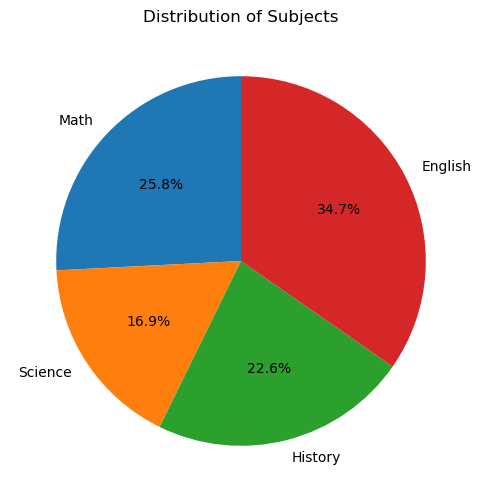

In [183]:
#Plot a pie chart showing the distribution of data in a given list of 
# categories, e.g., ['Math', 'Science', 'History', 'English'], with random values for each category.
categories = ['Math', 'Science', 'History', 'English']
values = np.random.randint(10, 100, size=4)

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(values,
        labels=categories,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Distribution of Subjects")
plt.show()

In [184]:
#Create a 3x3 matrix filled with random integers between 1 and 10.
#Transpose the matrix and then find the sum of each column.
matrix = np.random.randint(1, 11, (3, 3))
print(matrix)

transpose_matrix = matrix.T
print(transpose_matrix)
column_sum = np.sum(transpose_matrix, axis=0)
print(column_sum)


[[ 7  1  1]
 [ 8  6 10]
 [10  4  4]]
[[ 7  8 10]
 [ 1  6  4]
 [ 1 10  4]]
[ 9 24 18]


In [185]:
#Write a function that takes a NumPy array and returns the array after squaring all the elements.

def square_array(arr):
    return arr ** 2
arr = np.array([1, 2, 3, 4, 5])
result = square_array(arr)
print(arr)
print(result)

[1 2 3 4 5]
[ 1  4  9 16 25]


In [186]:
#Create a 5x5 NumPy array with random values and introduce some NaN (Not a Number) values.
#Use NumPy functions to fill in the NaN values with the column mean of the array.
arr = np.random.rand(5, 5)

arr[0, 2] = np.nan
arr[2, 1] = np.nan
arr[4, 3] = np.nan
print(arr)
column_mean = np.nanmean(arr, axis=0)

nan_indices = np.where(np.isnan(arr))

arr[nan_indices] = np.take(column_mean, nan_indices[1])

print("\nArray after replacing NaN values with column means:")
print(arr)

[[0.3794947  0.69582343        nan 0.16566092 0.54648299]
 [0.12750805 0.65566741 0.48830837 0.84821806 0.06030133]
 [0.7329012         nan 0.18284098 0.92070383 0.00543282]
 [0.77059299 0.11913129 0.67772603 0.94957692 0.94124831]
 [0.15116422 0.0205635  0.47744751        nan 0.88788382]]

Array after replacing NaN values with column means:
[[0.3794947  0.69582343 0.45658072 0.16566092 0.54648299]
 [0.12750805 0.65566741 0.48830837 0.84821806 0.06030133]
 [0.7329012  0.37279641 0.18284098 0.92070383 0.00543282]
 [0.77059299 0.11913129 0.67772603 0.94957692 0.94124831]
 [0.15116422 0.0205635  0.47744751 0.72103993 0.88788382]]
